In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive')

!mkdir -p olist-customer-intelligence/{data/raw,data/processed,notebooks,sql,src,models,reports,app/pages,docs}
os.chdir('/content/drive/MyDrive/M5-forecasting')
!touch src/__init__.py
print("Now in:", os.getcwd())

Now in: /content/drive/MyDrive/M5-forecasting


In [4]:

!kaggle competitions download -c m5-forecasting-accuracy -p data/raw
!unzip -o data/raw/m5-forecasting-accuracy.zip -d data/raw
!ls -lh data/raw

m5-forecasting-accuracy.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  data/raw/m5-forecasting-accuracy.zip
  inflating: data/raw/calendar.csv   
  inflating: data/raw/sales_train_evaluation.csv  
  inflating: data/raw/sales_train_validation.csv  
  inflating: data/raw/sample_submission.csv  
  inflating: data/raw/sell_prices.csv  
total 476M
-rw------- 1 root root 102K Jun  1  2020 calendar.csv
-rw------- 1 root root  46M Jun  1  2020 m5-forecasting-accuracy.zip
-rw------- 1 root root 117M Jun  1  2020 sales_train_evaluation.csv
-rw------- 1 root root 115M Jun  1  2020 sales_train_validation.csv
-rw------- 1 root root 5.0M Jun  1  2020 sample_submission.csv
-rw------- 1 root root 194M Jun  1  2020 sell_prices.csv


In [3]:
%%writefile src/data_prep.py

"""Data preparation for M5 hierarchical forecasting."""
import pandas as pd
import numpy as np


def load_raw(raw_dir="data/raw"):
    sales = pd.read_csv(f"{raw_dir}/sales_train_evaluation.csv")
    calendar = pd.read_csv(f"{raw_dir}/calendar.csv")
    prices = pd.read_csv(f"{raw_dir}/sell_prices.csv")
    return sales, calendar, prices

def melt_sales(sales, last_n_days=730):
    """Wide (d_1..d_N columns) -> long. Optionally keep only last N days."""
    id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
    day_cols = [c for c in sales.columns if c.startswith("d_")]
    if last_n_days is not None:
        day_cols = day_cols[-last_n_days:]
    long = sales.melt(
        id_vars=id_cols, value_vars=day_cols,
        var_name="d", value_name="sales"
    )
    long["sales"] = long["sales"].astype(np.int32)
    # downcast ID strings to categoricals (major memory saving)
    for c in id_cols:
        long[c] = long[c].astype("category")
    return long

def attach_calendar(long, calendar):
    cal = calendar[[
        "d", "date", "wm_yr_wk", "weekday", "wday", "month", "year",
        "event_name_1", "event_type_1", "event_name_2", "event_type_2",
        "snap_CA", "snap_TX", "snap_WI"
    ]].copy()
    long = long.merge(cal, on="d", how="left")
    long["date"] = pd.to_datetime(long["date"])
    return long


def attach_snap(long):
    """Pick the SNAP flag matching each row's state."""
    state = long["state_id"].values
    long["snap"] = np.select(
        [state == "CA", state == "TX", state == "WI"],
        [long["snap_CA"], long["snap_TX"], long["snap_WI"]],
        default=0
    ).astype(np.int8)
    return long.drop(columns=["snap_CA", "snap_TX", "snap_WI"])


def attach_prices(long, prices):
    long = long.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
    return long


def build_sales_long(raw_dir="data/raw", last_n_days=730):
    sales, calendar, prices = load_raw(raw_dir)
    long = melt_sales(sales, last_n_days=last_n_days)
    long = attach_calendar(long, calendar)
    long = attach_snap(long)
    long = attach_prices(long, prices)
    # downcast event columns
    for c in ["event_name_1", "event_type_1", "event_name_2", "event_type_2", "weekday"]:
        long[c] = long[c].astype("category")
    for c in ["wday", "month"]:
        long[c] = long[c].astype("int8")
    long["year"] = long["year"].astype("int16")
    return long


def build_hierarchical_map(sales):
    """The 12 M5 aggregation levels reference table (per-item leaf mapping)."""
    hmap = sales[[
        "id", "item_id", "dept_id", "cat_id", "store_id", "state_id"
    ]].drop_duplicates().reset_index(drop=True)
    hmap["total"] = "Total"
    return hmap

Overwriting src/data_prep.py


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src.data_prep import build_sales_long, build_hierarchical_map, load_raw
pd.set_option("display.max_columns", 50)

In [5]:
long = build_sales_long("data/raw", last_n_days=730)
print(long.shape)
print(long.memory_usage(deep=True).sum() / 1e9, "GB")
long.head()

(22257700, 20)
4.738629014 GB


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,8.26
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,2,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,3.97
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,2.97
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,2,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,4.64
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,1,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,3.08


In [7]:
long.head(100)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,8.26
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,2,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,3.97
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,2.97
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,2,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,4.64
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,1,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,3.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,HOBBIES_1_099_CA_1_evaluation,HOBBIES_1_099,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,15.48
96,HOBBIES_1_100_CA_1_evaluation,HOBBIES_1_100,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,10.98
97,HOBBIES_1_102_CA_1_evaluation,HOBBIES_1_102,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,0,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,4.98
98,HOBBIES_1_103_CA_1_evaluation,HOBBIES_1_103,HOBBIES_1,HOBBIES,CA_1,CA,d_1212,2,2014-05-24,11417,Saturday,1,5,2014,NaN,NaN,NaN,NaN,0,0.70


In [10]:
sales, _, _ = load_raw("data/raw")
hmap = build_hierarchical_map(sales)
hmap.to_csv("data/processed/hierarchical_map.csv", index=False)
print(hmap[["state_id","store_id","cat_id","dept_id"]].nunique())

state_id     3
store_id    10
cat_id       3
dept_id      7
dtype: int64


0.6944571990816661 share intermittent


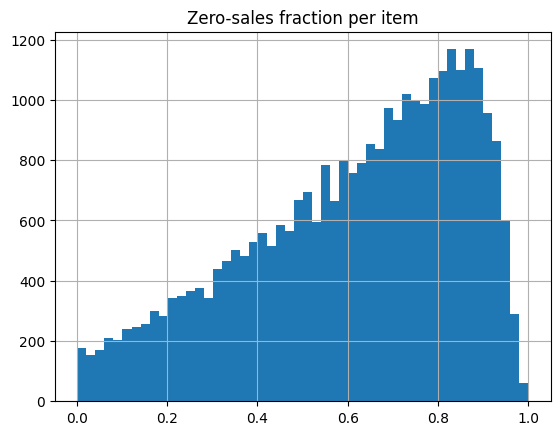

In [11]:
per_item = long.groupby("id", observed=True)["sales"].agg(
    zero_frac=lambda s: (s == 0).mean(),
    mean_sales="mean",
    nonzero_days=lambda s: (s > 0).sum(),
    total_days="count",
)
per_item["adi"] = per_item["total_days"] / per_item["nonzero_days"].replace(0, np.nan)
per_item["intermittent"] = per_item["zero_frac"] > 0.5
print(per_item["intermittent"].mean(), "share intermittent")
per_item["zero_frac"].hist(bins=50); plt.title("Zero-sales fraction per item"); plt.show()

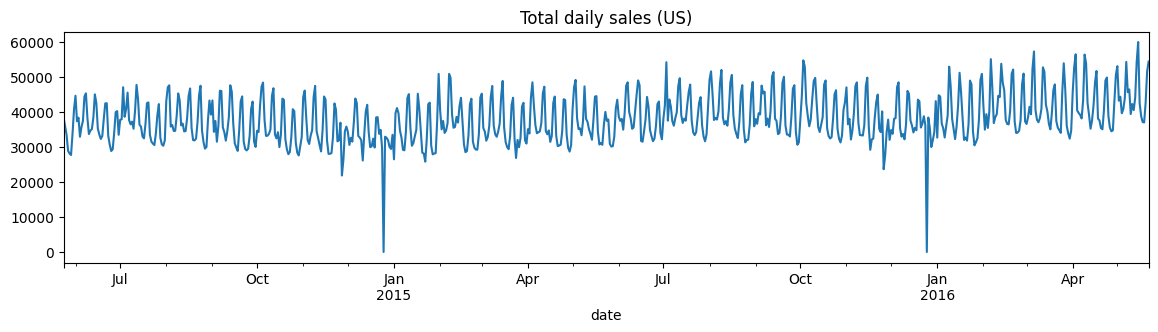

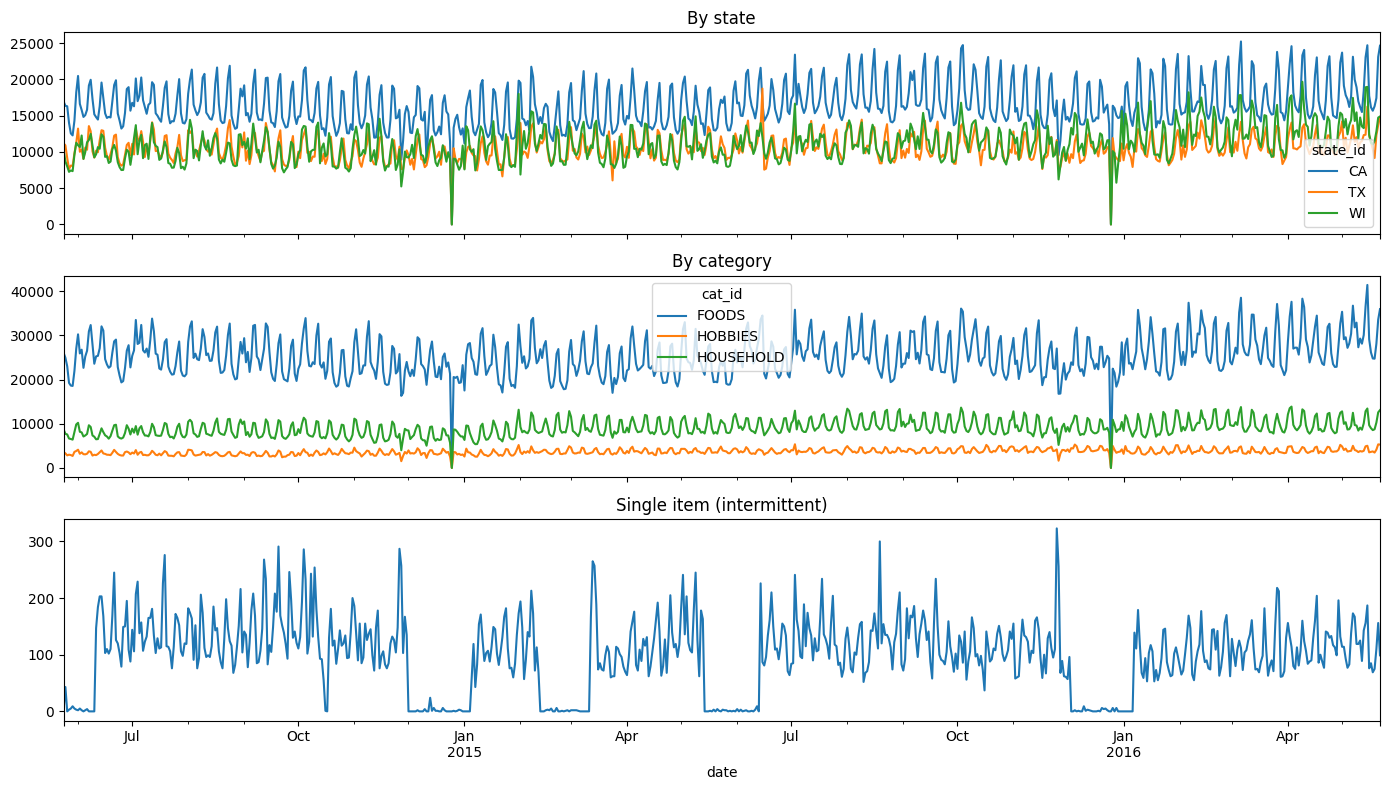

In [12]:
total = long.groupby("date", observed=True)["sales"].sum()
total.plot(figsize=(14,3), title="Total daily sales (US)"); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14,8), sharex=True)
long.groupby(["state_id","date"], observed=True)["sales"].sum().unstack("state_id").plot(ax=axes[0], title="By state")
long.groupby(["cat_id","date"], observed=True)["sales"].sum().unstack("cat_id").plot(ax=axes[1], title="By category")
long[long.id=="FOODS_3_090_CA_3_evaluation"].set_index("date")["sales"].plot(ax=axes[2], title="Single item (intermittent)")
plt.tight_layout(); plt.show()

## EDA, Hierarchy & Intermittency

**Data prepared**
- Melted M5 wide → long, last 730 days (2014-05-24 → 2016-05-22)
- 22.3M rows, downcast to ~4.7 GB (categoricals + int8/16)
- Joined calendar (dates, events, SNAP) and sell_prices
- Saved: `sales_long.parquet`, `hierarchical_map.csv`

**Hierarchy** (M5's 12 aggregation levels)
- 3 states → 10 stores → 3 categories → 7 depts → 3,049 items
- 30,490 leaf series (item × store)

**Intermittency — the key finding**
- **69.4% of series are intermittent** (>50% zero-sales days) -> 7 out of every 10 product-store combinations spend most days without any sale
- Severe at item level, smooth once aggregated → motivates hierarchical reconciliation
- Implication: point forecasts are inadequate; need probabilistic/quantile forecasts + newsvendor inventory logic

**Seasonality & structure**
- Strong weekly seasonality (weekend peaks) at all aggregation levels
- Upward demand trend across both years
- Two chain-wide zeros = Christmas closures (real, not missing) — must be modeled as events
- Sales ordering: CA ≫ TX ≈ WI (state); FOODS ≫ HOUSEHOLD ≫ HOBBIES (category)

**Caveats carried forward**
- Trained on last 2 years only (compute budget) — log in limitations.md
- `sell_price` NaN = item not yet on shelf → structural zeros